# 13 — Recall-guarded macro factor playbook (openai/gpt-oss-20b)

Excel storyboard S2–S4 (S1 = the no-recall screen, already persisted under `data/norecall_screen/`;
S5 and the non-PIT diagnostic line belong to nb14):

- S2 — naive directional eval of the selected model: coin-flip accuracy is the EXPECTED, CORRECT result.
- S3 — AI macro factor development on the numbers: regime loadings + per-rebalance `p_memorized` + factor stability.
- S4 — the deployable, PIT, recall-guarded portfolio line through the existing walk-forward, vectorbt sim and head-to-head.

Model-selection context (research.md 2026-07-03): the certified no-recall set is EMPTY; `openai/gpt-oss-20b`
was selected DESPITE carrying the sharpest recall signature of the screened pool (controlled screen AUC 0.926)
precisely because that makes the recall-guarding most measurable. Success in this notebook is NON-PREDICTIVE
throughout (R6.4): factor stability + measured memorization + non-degraded head-to-head — never forecast accuracy.

## 1. Setup

In [1]:
import json
import math
import os
import re
import sys
import warnings
from datetime import date
from pathlib import Path

warnings.filterwarnings("ignore")
REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
from dotenv import load_dotenv

import macro_framework as mf
from macro_framework import factor_scoring as fs
from macro_framework import steering
from recall_guard import NvidiaLM
from recall_guard.core.nvidia_lm import generate_many

load_dotenv(REPO / ".env")
pd.set_option("display.width", 200)

DATA = REPO / "data"
INIT_CASH = 10_000.0
SIM_START = "2019-01-01"
SIM_END = "2024-12-31"
LOOKBACK_DAYS = 756
TILT = 0.30  # nb09 final blend = 0.7*HRP + 0.3*BL

# R8 selection (research.md 2026-07-03): certified set EMPTY -> user selected gpt-oss-20b;
# production calibrator persisted at the model's TRUE cutoff 2024-06-01 (holdout_auc 0.9668, is_weak False).
NIM_MODEL = "openai/gpt-oss-20b"
CUTOFF = date(2024, 6, 1)
SLUG = NIM_MODEL.replace("/", "_")
CAL_DIR = DATA / f"factor_calibrator_{SLUG}"
TIMEOUT_S = 120.0  # reasoning model; NvidiaLM's 15 s default is too tight
MAX_WORKERS = 6

nvidia_key = (os.environ.get("NVIDIA_API_KEY") or "").strip()
if not nvidia_key:
    raise RuntimeError("NVIDIA_API_KEY not set in .env — required for the NIM generate/score paths")

spec = pd.read_parquet(DATA / "portfolio_ssr_top_per_category.parquet")
SYMBOLS = spec["symbol"].tolist()
asset_map = mf.AssetMap.default()
PANEL_Z_COLS = ["cpi_yoy_z", "t10y2y_z", "hy_oas_z"]

lm = NvidiaLM(api_key=nvidia_key, model=NIM_MODEL, timeout_s=TIMEOUT_S)
print("SYMBOLS:", SYMBOLS)
print("NIM model:", NIM_MODEL, "| cutoff:", CUTOFF.isoformat(), "| timeout_s:", TIMEOUT_S)

SYMBOLS: ['SWDA.L', 'XLK', 'IAU', 'BIL']
NIM model: openai/gpt-oss-20b | cutoff: 2024-06-01 | timeout_s: 120.0


## 2. Prices + macro panel (yfinance in-cell; the project price DB is absent here)

In [2]:
macro_panel = pd.read_parquet(DATA / "macro_panel_monthly.parquet")
macro_panel.index = pd.DatetimeIndex(macro_panel.index)
print("macro panel:", macro_panel.shape, "|", macro_panel.index.min().date(), "->", macro_panel.index.max().date())

# Daily prices (DB unavailable here -> public source; additive, no module change). Mirrors nb11.
def _fetch_prices() -> pd.DataFrame:
    import time
    import yfinance as yf
    want = SYMBOLS + ["SPY"]
    last_exc = None
    for attempt in range(6):
        try:
            raw = yf.download(want, start="2014-01-01", end=SIM_END,
                              auto_adjust=True, progress=False, threads=False)
            close = raw["Close"] if ("Close" in raw.columns.get_level_values(0)) else raw
            close = close[want].copy()
            close.index = pd.DatetimeIndex(close.index)
            if close[SYMBOLS].dropna(how="all").shape[0] > 1000:
                return close
        except Exception as exc:  # noqa: BLE001
            last_exc = exc
        time.sleep(8)
    raise RuntimeError(f"price fetch failed after retries: {last_exc!r}")

prices = _fetch_prices()
rebalance_dates = mf.monthly_rebalance_dates(prices[SYMBOLS], start=SIM_START, end=SIM_END)
all_returns = prices[SYMBOLS].pct_change()
print("prices:", prices.shape, "|", prices.index.min().date(), "->", prices.index.max().date())
print(f"{len(rebalance_dates)} monthly rebalances  {rebalance_dates[0].date()} -> {rebalance_dates[-1].date()}")

macro panel: (196, 6) | 2010-01-31 -> 2026-04-30
prices: (2828, 5) | 2014-01-02 -> 2024-12-30
72 monthly rebalances  2019-01-02 -> 2024-12-02


## S2 — No predictive alpha (naive directional eval)

For every walk-forward rebalance date the anonymized, date-free, PIT macro state is rendered into the
NAIVE directional prompt (`steering.render_directional` — the exact two answer lines
`Direction: <-1|0|1>` and `Confidence: <0..1>` for Asset_A = world equity, next period), sent to
gpt-oss-20b at temperature 0, and compared with the realized sign of the next-month SWDA.L
close-to-close return.

Framing — the point of this section: coin-flip accuracy is the EXPECTED, CORRECT result.
`recall_guard` measures *honesty*, not alpha. An anonymized, point-in-time macro state carries no
exploitable directional edge, and this model was chosen DESPITE maximal recall (controlled screen
AUC 0.926) to demonstrate guarding. No forecast-accuracy claim is made anywhere in this notebook.

In [3]:
def _asset_snapshot_stats(prices_hist: pd.DataFrame, returns_hist: pd.DataFrame) -> list[dict]:
    """Anonymized asset snapshot with trailing stats, mirroring nb09's track_a_fn / nb11."""
    def _t12m(col: pd.Series) -> float:
        p = col.dropna()
        return float(p.iloc[-1] / p.iloc[-253] - 1.0) if len(p) >= 253 else float("nan")

    def _vol(col: pd.Series) -> float:
        tail = col.dropna().tail(252)
        return float(tail.std(ddof=1) * np.sqrt(252)) if len(tail) >= 30 else float("nan")

    snap = []
    for real, pseudo in asset_map.real_to_pseudo.items():
        snap.append({
            "id": pseudo,
            "category": asset_map.categories[pseudo],
            "trailing_12m_return": _t12m(prices_hist[real]),
            "trailing_vol_ann": _vol(returns_hist[real]),
        })
    return snap


def _macro_state_asof(rb: pd.Timestamp) -> dict | None:
    mz = macro_panel[PANEL_Z_COLS].dropna()
    asof = mz[mz.index < rb]
    return asof.iloc[-1].to_dict() if not asof.empty else None


def _generate_big(prompts: list, max_tokens: int = 2048) -> list:
    """Parallel generate with a larger completion budget (retry path).

    gpt-oss-20b is a reasoning model: under load it can burn the default
    512-token budget on its reasoning chain before emitting the requested
    final lines / JSON. Retries run at 2048 tokens so a transient truncation
    does not become a permanently failed row; a repeat failure IS kept as a
    failed row (the module fallbacks handle it downstream)."""
    from concurrent.futures import ThreadPoolExecutor

    def _one(p):
        try:
            return lm.generate(p, max_tokens=max_tokens)
        except Exception as exc:  # noqa: BLE001 -- keep the failure recorded as a failed row
            return exc

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        return list(ex.map(_one, prompts))


def _retry_failed(replies: list, prompts: list) -> list:
    """Resilience: one batched bigger-budget retry per failed generate."""
    out = list(replies)
    bad = [i for i, r in enumerate(out) if isinstance(r, BaseException)]
    if bad:
        for i, r in zip(bad, _generate_big([prompts[i] for i in bad])):
            out[i] = r
    return out


naive_rows = []  # (rb, prompt) — anonymized, date-free, PIT
for rb in rebalance_dates:
    price_hist = prices[SYMBOLS].loc[prices.index < rb].tail(LOOKBACK_DAYS)
    ret_hist = all_returns.loc[all_returns.index < rb].tail(LOOKBACK_DAYS).dropna(how="any")
    if price_hist.shape[0] < 60 or ret_hist.shape[0] < 60:
        continue
    macro_state = _macro_state_asof(rb)
    if macro_state is None:
        continue
    naive_rows.append((rb, steering.render_directional(macro_state, _asset_snapshot_stats(price_hist, ret_hist))))

naive_prompts = [p for _, p in naive_rows]
print(f"naive directional prompts: {len(naive_prompts)}")
naive_replies = _retry_failed(generate_many(lm, naive_prompts, max_workers=MAX_WORKERS), naive_prompts)
n_gen_fail = sum(isinstance(r, BaseException) for r in naive_replies)
print(f"replies: {len(naive_replies)}  failed after retry: {n_gen_fail}")

naive directional prompts: 72
replies: 72  failed after retry: 0


In [4]:
_DIR_RE = re.compile(r"Direction[\s\*_:]*(-?1|0)")
_CONF_RE = re.compile(r"Confidence[\s\*_:]*([01](?:\.\d+)?|\.\d+)")

# Format-retry: a reply that never emitted the required final lines gets ONE batched
# bigger-budget regeneration (reasoning-truncation guard); a repeat failure stays a failed row.
_fmt_bad = [i for i, r in enumerate(naive_replies)
            if isinstance(r, BaseException) or not _DIR_RE.search(r.content)]
if _fmt_bad:
    for i, r in zip(_fmt_bad, _generate_big([naive_prompts[i] for i in _fmt_bad])):
        naive_replies[i] = r
    print(f"format-retried {len(_fmt_bad)} naive replies at max_tokens=2048")

swda = prices["SWDA.L"].ffill()  # Asset_A = world equity; realized = sign of next-month close-to-close return


def _realized_dir(rb: pd.Timestamp, nxt: pd.Timestamp) -> int:
    p0, p1 = float(swda.asof(rb)), float(swda.asof(nxt))
    return int(np.sign(p1 / p0 - 1.0))


# Next-period end per rebalance date (the following rebalance; the stream's last
# date closes on the final available trading day).
_next_rb = {rb: (rebalance_dates[i + 1] if i + 1 < len(rebalance_dates) else swda.index.max())
            for i, rb in enumerate(rebalance_dates)}

records = []
for (rb, prompt), reply in zip(naive_rows, naive_replies):
    realized = _realized_dir(rb, _next_rb[rb])
    if isinstance(reply, BaseException):
        records.append({"date": rb, "prompt": prompt, "reply": f"<generate failed: {type(reply).__name__}>",
                        "predicted_direction": None, "confidence": None,
                        "realized_direction": realized, "correct": None})
        continue
    text = reply.content
    dm = _DIR_RE.findall(text)
    cm = _CONF_RE.findall(text)
    pred = int(dm[-1]) if dm else None
    conf = float(cm[-1]) if cm else None
    records.append({"date": rb, "prompt": prompt, "reply": text,
                    "predicted_direction": pred, "confidence": conf,
                    "realized_direction": realized,
                    "correct": (pred == realized) if pred is not None else None})

naive_df = pd.DataFrame(records)
naive_path = DATA / f"naive_directional_eval_{SLUG}.parquet"
naive_df.to_parquet(naive_path)
print("wrote", naive_path.name, naive_df.shape)


def wilson_ci(k: int, n: int, z: float = 1.96) -> tuple[float, float]:
    if n == 0:
        return (float("nan"), float("nan"))
    p = k / n
    denom = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    return center - half, center + half


directional = naive_df[naive_df["predicted_direction"].isin([-1, 1])]
n_dir = len(directional)
n_correct = int((directional["predicted_direction"] == directional["realized_direction"]).sum())
acc = n_correct / n_dir if n_dir else float("nan")
ci_lo, ci_hi = wilson_ci(n_correct, n_dir)
n_zero = int((naive_df["predicted_direction"] == 0).sum())
n_unparsed = int(naive_df["predicted_direction"].isna().sum())

print(f"naive directional accuracy (Asset_A, next month): {acc:.3f}  "
      f"Wilson 95% CI [{ci_lo:.3f}, {ci_hi:.3f}]  (n={n_dir}; flat predictions={n_zero}, unparsed={n_unparsed})")
print(f"0.5 inside the CI: {ci_lo <= 0.5 <= ci_hi}")
print()
print("FRAMING: coin-flip is the EXPECTED, CORRECT result. recall_guard measures honesty, not alpha —")
print("this model was chosen DESPITE maximal recall (controlled screen AUC 0.926) to demonstrate")
print("guarding. No forecast-accuracy claim is made from this table.")

format-retried 5 naive replies at max_tokens=2048
wrote naive_directional_eval_openai_gpt-oss-20b.parquet (72, 7)
naive directional accuracy (Asset_A, next month): 0.394  Wilson 95% CI [0.289, 0.511]  (n=71; flat predictions=1, unparsed=0)
0.5 inside the CI: True

FRAMING: coin-flip is the EXPECTED, CORRECT result. recall_guard measures honesty, not alpha —
this model was chosen DESPITE maximal recall (controlled screen AUC 0.926) to demonstrate
guarding. No forecast-accuracy claim is made from this table.


## S3 — AI macro factor development (numbers)

Per rebalance date: `render_regime_loadings_prompt(macro_state, asset_snapshot)` (anonymized, PIT) →
gpt-oss-20b loadings reply → `parse_loadings` → the five-axis factor vector; the SAME prompt is scored
for `p_memorized` by the persisted number-native `FactorScorer` (identifying-vs-anonymized calibration
on the factor task; no news/FMP). Artifacts: `factor_loadings_v1.parquet`, `factor_scores_v1.parquet`,
`factor_views_v1.parquet`, `factor_stability_v1.json`.

In [5]:
def lm_factory(key: str, model: str) -> NvidiaLM:
    return NvidiaLM(api_key=key, model=model, timeout_s=TIMEOUT_S)


scorer = fs.FactorScorer.load(CAL_DIR, api_key=nvidia_key, lm_factory=lm_factory)
print(f"FactorScorer loaded from {CAL_DIR.name}: holdout_auc={scorer.holdout_auc:.4f}  is_weak={scorer.is_weak}")
print("calibration stats:", scorer.stats)
assert scorer.is_weak is False, "calibrator weak -> guard would pass through (R4.3); expected strong per research.md"
print("=> STRONG calibrator: the recall_guarded_adjust discount ENGAGES on the S4 line (R4.3).")

FactorScorer loaded from factor_calibrator_openai_gpt-oss-20b: holdout_auc=0.9668  is_weak=False
calibration stats: CalibrationStats(holdout_auc=0.9667774086378738, is_weak=False, n_is=170, n_oos=170)
=> STRONG calibrator: the recall_guarded_adjust discount ENGAGES on the S4 line (R4.3).


In [6]:
# The factor prompt's asset snapshot matches the calibration corpus exactly:
# pseudo id + category only (the module's _asset_snapshot_from_map form), so the
# scored prompts come from the calibrated distribution.
FACTOR_SNAPSHOT = [
    {"id": pseudo, "category": cat} for pseudo, cat in sorted(asset_map.categories.items())
]

factor_meta = []  # (rb, macro_state, prompt) — anonymized PIT regime-loadings task
for rb in rebalance_dates:
    macro_state = _macro_state_asof(rb)
    if macro_state is None:
        continue
    factor_meta.append((rb, macro_state, fs.render_regime_loadings_prompt(macro_state, FACTOR_SNAPSHOT)))

factor_prompts = [p for _, _, p in factor_meta]
print(f"factor prompts: {len(factor_prompts)}")
factor_replies = _retry_failed(generate_many(lm, factor_prompts, max_workers=MAX_WORKERS), factor_prompts)


def _reply_text(reply) -> str:
    return "" if isinstance(reply, BaseException) else reply.content


texts = [_reply_text(r) for r in factor_replies]
parsed = [fs.parse_loadings(t, m[0]) for m, t in zip(factor_meta, texts)]

# Format-retry: ONE batched bigger-budget regeneration for any reply that did not
# yield the full five-axis vector (reasoning-truncation guard); a repeat failure
# stays a failed row (parse_ok False) that the module fallbacks handle downstream.
_bad = [i for i, rl in enumerate(parsed) if rl is None]
if _bad:
    for i, r in zip(_bad, _generate_big([factor_prompts[i] for i in _bad])):
        texts[i] = _reply_text(r)
        parsed[i] = fs.parse_loadings(texts[i], factor_meta[i][0])
    print(f"format-retried {len(_bad)} loadings replies at max_tokens=2048; "
          f"still unparsed: {sum(1 for i in _bad if parsed[i] is None)}")

reply_by_prompt: dict[str, str] = {}
loadings_by_date: dict[pd.Timestamp, fs.RegimeLoadings | None] = {}
load_rows = []
for (rb, _, prompt), text, rl in zip(factor_meta, texts, parsed):
    reply_by_prompt[prompt] = text
    loadings_by_date[rb] = rl
    row = {"date": rb, "parse_ok": rl is not None}
    for axis in fs.MACRO_AXES:
        row[axis] = rl.loadings[axis] if rl is not None else float("nan")
    load_rows.append(row)

loadings_df = pd.DataFrame(load_rows).set_index("date")
loadings_path = DATA / "factor_loadings_v1.parquet"
loadings_df.to_parquet(loadings_path)
n_parsed = int(loadings_df["parse_ok"].sum())
print(f"parsed loadings: {n_parsed}/{len(loadings_df)}  -> wrote {loadings_path.name}")
loadings_df.head(4)

factor prompts: 72
format-retried 38 loadings replies at max_tokens=2048; still unparsed: 1
parsed loadings: 71/72  -> wrote factor_loadings_v1.parquet


,parse_ok,inflation,growth,credit_stress,policy,risk_appetite
date,,,,,,
2019-01-02,True,0.55,-1.00,0.65,1.0,-0.8
2019-02-01,True,-0.03,-0.18,0.80,0.7,-0.6
2019-03-01,True,0.00,-0.80,-0.40,-0.6,-0.7
2019-04-01,True,0.40,-0.60,-0.50,-0.7,-0.5


wrote factor_scores_v1.parquet  scored ok: 72/72
p_memorized distribution: mean=0.3080 median=0.3113 min=0.0000 max=0.8734 p90=0.6129


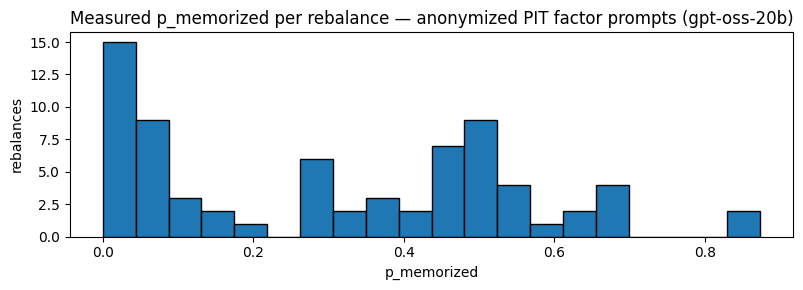

In [7]:
factor_scores = list(scorer.score_many(factor_prompts, max_workers=MAX_WORKERS))
# Resilience: one individual retry per failed score; a second failure stays an unscored
# row (p_memorized None) that the module's R4.3 fallbacks handle downstream.
for i, sc in enumerate(factor_scores):
    if sc.p_memorized is None:
        factor_scores[i] = scorer.score(factor_prompts[i])

score_by_prompt = {p: sc for p, sc in zip(factor_prompts, factor_scores)}
scores_df = pd.DataFrame({
    "date": [rb for rb, _, _ in factor_meta],
    "p_memorized": [sc.p_memorized for sc in factor_scores],
    "fail_reason": [sc.fail_reason for sc in factor_scores],
}).set_index("date")
scores_path = DATA / "factor_scores_v1.parquet"
scores_df.to_parquet(scores_path)

pm = scores_df["p_memorized"].dropna().astype(float)
print(f"wrote {scores_path.name}  scored ok: {len(pm)}/{len(scores_df)}")
print(f"p_memorized distribution: mean={pm.mean():.4f} median={pm.median():.4f} "
      f"min={pm.min():.4f} max={pm.max():.4f} p90={pm.quantile(0.9):.4f}")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(pm, bins=20, edgecolor="black")
ax.set_title("Measured p_memorized per rebalance — anonymized PIT factor prompts (gpt-oss-20b)")
ax.set_xlabel("p_memorized")
ax.set_ylabel("rebalances")
plt.tight_layout()
plt.show()

In [8]:
# Per-asset tilt views: raw vs recall-guarded (guarded_tilt = raw_tilt * (1 - p_memorized)).
# Conviction is the same dimensionless clipped-L2 helper factor_rebalance uses.
from macro_framework.factor_scoring import _conviction_from_loadings

view_rows = []
for (rb, _, prompt) in factor_meta:
    rl = loadings_by_date[rb]
    if rl is None:
        continue
    conviction = _conviction_from_loadings(rl)
    raw_views = fs.loadings_to_tilt_views(rl, FACTOR_SNAPSHOT, asset_map, conviction)
    p_mem = score_by_prompt[prompt].p_memorized
    guarded_views = fs.recall_guarded_adjust(raw_views, p_mem)  # passthrough when p_mem is None (R4.3)
    for rv, gv in zip(raw_views, guarded_views):
        view_rows.append({
            "date": rb,
            "asset": rv.asset_long,
            "raw_tilt": float(rv.expected_excess_annualized),
            "p_memorized": p_mem,
            "guarded_tilt": float(gv.expected_excess_annualized),
            "conviction": float(conviction),
        })

views_df = pd.DataFrame(view_rows)
views_path = DATA / "factor_views_v1.parquet"
views_df.to_parquet(views_path)
print(f"wrote {views_path.name}  rows: {len(views_df)}  (guarded_tilt = raw_tilt * (1 - p_memorized))")
views_df.head(8)

wrote factor_views_v1.parquet  rows: 284  (guarded_tilt = raw_tilt * (1 - p_memorized))


,date,asset,raw_tilt,p_memorized,guarded_tilt,conviction
0,2019-01-02,Asset_A,-2.465,0.292040,-1.745120,0.820366
1,2019-01-02,Asset_B,-2.925,0.292040,-2.070782,0.820366
2,2019-01-02,Asset_C,1.795,0.292040,1.270787,0.820366
3,2019-01-02,Asset_D,2.435,0.292040,1.723881,0.820366
4,2019-02-01,Asset_A,-1.381,0.604141,-0.546681,0.551960
5,2019-02-01,Asset_B,-1.552,0.604141,-0.614373,0.551960
6,2019-02-01,Asset_C,0.978,0.604141,0.387150,0.551960
7,2019-02-01,Asset_D,1.499,0.604141,0.593393,0.551960


In [9]:
stability = fs.factor_stability({rb: rl for rb, rl in loadings_by_date.items() if rl is not None})
stability_path = DATA / "factor_stability_v1.json"
stability_path.write_text(json.dumps(stability, indent=2, sort_keys=True))
stab_tbl = pd.DataFrame({
    "std": {a: stability[f"{a}_std"] for a in fs.MACRO_AXES},
    "mean_abs_change": {a: stability[f"{a}_mac"] for a in fs.MACRO_AXES},
}).round(4)
print(f"wrote {stability_path.name}  overall: mean_std={stability['mean_std']:.4f} mean_mac={stability['mean_mac']:.4f}")
stab_tbl

wrote factor_stability_v1.json  overall: mean_std=0.5502 mean_mac=0.4200


,std,mean_abs_change
inflation,0.6334,0.1436
growth,0.4623,0.4929
credit_stress,0.6595,0.5541
policy,0.5815,0.5100
risk_appetite,0.4142,0.3994


## S4 — Recall-guarded portfolio line (the deployable, PIT line)

`make_factor_weight_fn` composes renderer → loadings → parse → tilt-as-exposure → recall-guarded
discount → the UNCHANGED `views_to_bl`; nb09's EXISTING base-allocation/blend math is injected via
`combine` (HRP-CVaR base with BIL pinned at 25%, BL posterior `obj="Utility"`, 0.7·HRP + 0.3·BL,
TILT=0.30) — the module composes, the notebook injects, nothing is duplicated (R3.3/R6.1).
The S3 replies and scores are replayed (no extra NIM calls), so this line is driven by EXACTLY the
loadings and `p_memorized` values persisted above.

In [10]:
class _PreScoredFactorScorer:
    """Replay scorer exposing the exact surface factor_rebalance uses (is_weak + score).

    Backed by the S3 scores keyed on the rendered prompt string, so no NIM call
    happens during the walk-forward; an unseen prompt degrades to an unscored
    result and the module's R4.3 passthrough handles it."""

    is_weak = False  # the loaded calibrator is strong (asserted in S3)

    def __init__(self, by_prompt: dict) -> None:
        self._by_prompt = by_prompt

    def score(self, prompt: str):
        sc = self._by_prompt.get(prompt)
        if sc is None:
            return fs.FactorScore(p_memorized=None, parse_ok=False, fail_reason="not_pre_scored")
        return sc


prescored = _PreScoredFactorScorer(score_by_prompt)


def generate_loadings(prompt: str) -> str:
    """Replay the S3 gpt-oss-20b loadings reply for this prompt (no extra NIM calls)."""
    return reply_by_prompt.get(prompt, "")


# A real agent instance purely for its UNCHANGED views_to_bl (pure AssetMap math; no LLM call).
bl_agent = mf.LlmMacroAgent(asset_map=asset_map)


def build_inputs(ctx):
    """Walk-forward ctx -> (macro_state, asset_snapshot, as_of, raw_levels) for factor_rebalance."""
    mz = ctx["macro_panel"][PANEL_Z_COLS].dropna()
    macro_state = mz.iloc[-1].to_dict()  # ctx macro_panel is already sliced strictly-before rb
    return macro_state, FACTOR_SNAPSHOT, ctx["rebalance_date"], None


def combine(ctx, P, Q):
    """nb09's allocation, injected UNCHANGED: HRP-CVaR base (BIL pinned 25%) + BL posterior, 0.7/0.3 blend."""
    returns_hist = ctx["returns"]
    w_hrp = mf.hrp_cvar_weights_with_fixed(returns_hist, {"BIL": 0.25})
    if P is None:
        return w_hrp
    try:
        w_bl = mf.bl_mv_weights(returns_hist, prior_weights=w_hrp, P=P, Q=Q, obj="Utility")
    except Exception:  # noqa: BLE001 -- BL can fail on degenerate inputs; fall back to base
        return w_hrp
    w = (1.0 - TILT) * w_hrp + TILT * w_bl
    return w / w.sum()


factor_weight_fn = fs.make_factor_weight_fn(
    generate_loadings=generate_loadings,
    scorer=prescored,
    agent=bl_agent,
    build_inputs=build_inputs,
    combine=combine,
)

# Per-rebalance decision capture (mirrors nb11's steered-log loop; replay -> network-free).
decision_log = {"p_memorized": {}, "parse_ok": {}, "steered": {}, "conviction": {},
                "loadings": {}, "views": {}}
for rb in rebalance_dates:
    macro_hist = macro_panel.loc[macro_panel.index < rb]
    price_hist = prices[SYMBOLS].loc[prices.index < rb].tail(LOOKBACK_DAYS)
    ret_hist = all_returns.loc[all_returns.index < rb].tail(LOOKBACK_DAYS).dropna(how="any")
    if macro_hist.empty or price_hist.shape[0] < 60 or ret_hist.shape[0] < 60:
        continue
    ctx = {"rebalance_date": rb, "prices": price_hist, "returns": ret_hist, "macro_panel": macro_hist}
    macro_state, snap, as_of, raw_levels = build_inputs(ctx)
    dec = fs.factor_rebalance(
        generate_loadings=generate_loadings, scorer=prescored, agent=bl_agent,
        macro_state=macro_state, asset_snapshot=snap, real_symbols=SYMBOLS, as_of=as_of)
    decision_log["p_memorized"][rb] = dec.p_memorized
    decision_log["parse_ok"][rb] = bool(dec.parse_ok)
    decision_log["steered"][rb] = bool(dec.steered)
    decision_log["conviction"][rb] = float(dec.views[0].confidence) if dec.views else None
    decision_log["loadings"][rb] = dict(dec.loadings.loadings) if dec.loadings is not None else None
    decision_log["views"][rb] = [v.to_dict() for v in dec.views]

n_guarded = sum(1 for v in decision_log["steered"].values() if v)
print(f"recall-guarded decisions: {n_guarded}/{len(decision_log['steered'])} "
      f"(rest fell back to base/unadjusted per R4.3)")

recall-guarded decisions: 71/72 (rest fell back to base/unadjusted per R4.3)


In [11]:
factor_targets = mf.build_walk_forward_targets(
    prices[SYMBOLS],
    rebalance_dates=rebalance_dates,
    weight_fns={"track_a_factor": factor_weight_fn},
    macro_panel=macro_panel,
    lookback_days=LOOKBACK_DAYS,
)["track_a_factor"]
print("factor target rows:", factor_targets.dropna(how="all").shape[0], "/", len(rebalance_dates))

factor_pf = mf.run_rebalance_sim(prices[SYMBOLS], factor_targets, init_cash=INIT_CASH)
factor_equity = factor_pf.value()
print("factor line total_return:", round(float(factor_pf.total_return()), 4),
      "| final equity:", round(float(factor_equity.iloc[-1]), 2))

targets_path = DATA / "factor_targets_v1.parquet"
equity_path = DATA / "factor_equity_v1.parquet"
dlog_path = DATA / "factor_decision_log_v1.json"
factor_targets.to_parquet(targets_path)
factor_equity.to_frame("value").to_parquet(equity_path)
dlog = {
    "meta": {
        "nim_model": NIM_MODEL, "cutoff_date": CUTOFF.isoformat(),
        "holdout_auc": float(scorer.holdout_auc), "is_weak": bool(scorer.is_weak),
        "n_rebalances": len(decision_log["steered"]), "n_recall_guarded": int(n_guarded),
        "line": "PIT anonymized deployable (recall-guarded); the non-PIT diagnostic line is nb14",
    },
    **{k: {str(d): v for d, v in dd.items()} for k, dd in decision_log.items()},
}
dlog_path.write_text(json.dumps(dlog, indent=2, default=str))
for p in (targets_path, equity_path, dlog_path):
    print("wrote", p.name, "->", p.exists())

factor target rows: 72 / 72
factor line total_return: 0.8222 | final equity: 18222.34
wrote factor_targets_v1.parquet -> True
wrote factor_equity_v1.parquet -> True
wrote factor_decision_log_v1.json -> True


### Head-to-head: Baseline / Track A (LLM) / Track B (MC-Nash) + Track A (factor)

In [12]:
tgt_baseline = pd.read_parquet(DATA / "baseline_targets_2019_2024.parquet")
tgt_track_a = pd.read_parquet(DATA / "track_a_targets_2019_2024.parquet")
tgt_track_b = pd.read_parquet(DATA / "track_b_targets_2019_2024.parquet")

pfs = {
    "Baseline":          mf.run_rebalance_sim(prices[SYMBOLS], tgt_baseline, init_cash=INIT_CASH),
    "Track A (LLM)":     mf.run_rebalance_sim(prices[SYMBOLS], tgt_track_a, init_cash=INIT_CASH),
    "Track B (MC-Nash)": mf.run_rebalance_sim(prices[SYMBOLS], tgt_track_b, init_cash=INIT_CASH),
    "Track A (factor)":  factor_pf,
}
targets = {
    "Baseline": tgt_baseline,
    "Track A (LLM)": tgt_track_a,
    "Track B (MC-Nash)": tgt_track_b,
    "Track A (factor)": factor_targets,
}
report = mf.head_to_head_report(pfs, targets, crisis_start="2022-01-01", crisis_end="2022-12-31")
report.round(4)

,total_return,annualized_return,annualized_vol,sharpe,sortino,calmar,max_drawdown,crisis_return,crisis_max_drawdown,defensive_lead_date,avg_turnover
Baseline,0.158363,0.019945,0.069255,0.319854,0.435337,0.112586,-0.177156,-0.147272,-0.171918,2019-01-02,0.409345
Track A (LLM),1.110504,0.105549,0.084465,1.230358,1.809647,0.815935,-0.129359,-0.050779,-0.129359,2019-01-02,0.094113
Track B (MC-Nash),0.916609,0.091328,0.115772,0.813043,1.140938,0.370695,-0.24637,-0.113228,-0.161083,2020-11-02,0.163334
Track A (factor),0.822234,0.08395,0.071846,1.158033,1.709604,0.736068,-0.114052,-0.035774,-0.113086,2019-01-02,0.279609


In [13]:
factor_row = report.loc["Track A (factor)"]
base_row = report.loc["Baseline"]
ta_row = report.loc["Track A (LLM)"]

print("=== Non-predictive success definition (R6.4 / task 4.1) ===")
print(f"1. Factor stability: mean_std={stability['mean_std']:.4f}, mean_mac={stability['mean_mac']:.4f} "
      f"(per-axis table above; parsed {n_parsed}/{len(loadings_df)})")
print(f"2. Memorization distribution: mean={pm.mean():.4f}, median={pm.median():.4f}, "
      f"min={pm.min():.4f}, max={pm.max():.4f} — every guarded tilt scaled by (1 - p_memorized)")
print(f"3. Head-to-head non-degradation: Track A (factor) sharpe={factor_row['sharpe']:.4f} "
      f"vs Baseline {base_row['sharpe']:.4f} / Track A (LLM) {ta_row['sharpe']:.4f}; "
      f"max_dd={factor_row['max_drawdown']:.4f}")
print(f"   Turnover: Track A (factor) avg_turnover={factor_row['avg_turnover']:.4f} "
      f"(Baseline {base_row['avg_turnover']:.4f}, Track A (LLM) {ta_row['avg_turnover']:.4f})")
print()
print("Success = stable factor loadings + measured (guarded) memorization + a non-degraded")
print("head-to-head line. NO forecast-accuracy claim is made — S2 showed the expected coin flip.")

=== Non-predictive success definition (R6.4 / task 4.1) ===
1. Factor stability: mean_std=0.5502, mean_mac=0.4200 (per-axis table above; parsed 71/72)
2. Memorization distribution: mean=0.3080, median=0.3113, min=0.0000, max=0.8734 — every guarded tilt scaled by (1 - p_memorized)
3. Head-to-head non-degradation: Track A (factor) sharpe=1.1580 vs Baseline 0.3199 / Track A (LLM) 1.2304; max_dd=-0.1141
   Turnover: Track A (factor) avg_turnover=0.2796 (Baseline 0.4093, Track A (LLM) 0.0941)

Success = stable factor loadings + measured (guarded) memorization + a non-degraded
head-to-head line. NO forecast-accuracy claim is made — S2 showed the expected coin flip.


## Research log (append-only, final cell)

Appends ONE dated entry to the spec research log; guarded on the exact heading so re-running
this cell never duplicates it, and earlier entries are never touched.

In [14]:
RESEARCH = REPO / ".kiro/specs/version-aware-factor-scoring/research.md"
HEADING = "## 2026-07-03 — nb13 recall-guarded factor playbook (S2–S4 live run)"

text = RESEARCH.read_text(encoding="utf-8")
if HEADING in text:
    print("research.md already carries the nb13 entry — append skipped (append-only, idempotent).")
else:
    stab_std, stab_mac = stability["mean_std"], stability["mean_mac"]
    n_dec = len(decision_log["steered"])
    tb_sharpe = float(report.loc["Track B (MC-Nash)"]["sharpe"])
    fr_tr, fr_sh = float(factor_row["total_return"]), float(factor_row["sharpe"])
    fr_dd, fr_cr = float(factor_row["max_drawdown"]), float(factor_row["crisis_return"])
    fr_to = float(factor_row["avg_turnover"])
    entry = f"""

---

{HEADING}

_nb13 executed end-to-end on the selected model `{NIM_MODEL}` (persisted calibrator
`{CAL_DIR.name}`: holdout_auc={scorer.holdout_auc:.4f}, is_weak={scorer.is_weak}); yfinance prices
in-cell; artifacts under `data/` (price-dependent factor targets/equity/decision-log gitignored,
shipped via the GH data release)._

- **S2 naive directional eval** (`{naive_path.name}`): accuracy={acc:.3f}, Wilson 95% CI
  [{ci_lo:.3f}, {ci_hi:.3f}] over n={n_dir} directional predictions (flat={n_zero},
  unparsed={n_unparsed}); 0.5 inside the CI: {ci_lo <= 0.5 <= ci_hi}. Coin-flip is the EXPECTED,
  CORRECT result — recall_guard measures honesty, not alpha; the model was selected DESPITE maximal
  recall (screen AUC 0.926) to make the guarding measurable.
- **S3 factors**: {n_parsed}/{len(loadings_df)} loadings parsed; p_memorized mean={pm.mean():.4f},
  median={pm.median():.4f}, min={pm.min():.4f}, max={pm.max():.4f}, p90={pm.quantile(0.9):.4f}
  (`{scores_path.name}`, `{loadings_path.name}`, `{views_path.name}`); factor stability
  mean_std={stab_std:.4f}, mean_mac={stab_mac:.4f} (`{stability_path.name}`).
- **S4 recall-guarded PIT line**: {n_guarded}/{n_dec} rebalances guarded (tilt × (1−p_mem));
  head-to-head row Track A (factor): total_return={fr_tr:.4f}, sharpe={fr_sh:.4f},
  max_dd={fr_dd:.4f}, crisis_return={fr_cr:.4f}, avg_turnover={fr_to:.4f}
  (Baseline sharpe {base_row['sharpe']:.4f}, Track A (LLM) {ta_row['sharpe']:.4f},
  Track B {tb_sharpe:.4f}).
- Success stays non-predictive (R6.4): factor stability + the measured memorization distribution +
  a non-degraded head-to-head — no forecast-accuracy claim. S5 (SSR luck-vs-skill) and the non-PIT
  diagnostic line are nb14 (task 4.2).
"""
    RESEARCH.write_text(text + entry, encoding="utf-8")
    print(f"research.md: appended one dated entry: {HEADING}")

research.md already carries the nb13 entry — append skipped (append-only, idempotent).
